# Qwen2.5-VL Fine-Tuning Visualizations

Bu notebook, Drive üzerinde kayıtlı fine-tuning çıktılarından sunum/rapor için görseller üretir.

Üretilenler:
- Training Loss Curve
- Smoothed Training Loss Curve
- Learning Rate Schedule
- Training Configuration Table
- LoRA Configuration Table
- Output Artifact Summary
- Fine-Tuning Pipeline Diagram
- Ziplenmiş figür dosyaları

> Bu notebook modeli yeniden eğitmez.

## 1. Drive Bağlama

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Path Ayarları

In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project")
OUTPUT_DIR = BASE_DIR / "outputs" / "qwen25vl_foodextract_lora_full"
EVAL_DIR = BASE_DIR / "eval"
FIG_DIR = EVAL_DIR / "finetune_figures"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR exists:", OUTPUT_DIR.exists())
print("FIG_DIR:", FIG_DIR)

BASE_DIR: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project
OUTPUT_DIR exists: True
FIG_DIR: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures


## 3. Output Klasörü İçeriği

In [ ]:
import pandas as pd

files = []
for p in OUTPUT_DIR.iterdir():
    size_mb = p.stat().st_size / (1024 * 1024) if p.is_file() else None
    files.append({
        "name": p.name,
        "type": "folder" if p.is_dir() else "file",
        "size_mb": round(size_mb, 2) if size_mb is not None else "-"
    })

df_files = pd.DataFrame(files).sort_values(["type", "name"])
display(df_files)

,name,type,size_mb
3,README.md,file,0.0
5,adapter_config.json,file,0.0
4,adapter_model.safetensors,file,114.26
6,chat_template.jinja,file,0.0
2,config.json,file,0.0
10,non_lora_state_dict.bin,file,70.02
9,processor_config.json,file,0.0
8,tokenizer.json,file,10.89
7,tokenizer_config.json,file,0.0
1,trainer_state.json,file,0.01


## 4. Trainer State Yükleme

In [ ]:
import json

trainer_state_path = OUTPUT_DIR / "trainer_state.json"

if not trainer_state_path.exists():
    raise FileNotFoundError(f"trainer_state.json bulunamadı: {trainer_state_path}")

with open(trainer_state_path, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)

print("Global step:", trainer_state.get("global_step"))
print("Epoch:", trainer_state.get("epoch"))

Global step: 48
Epoch: 1.0


## 5. Loss ve Learning Rate Logları

In [ ]:
df_logs = pd.DataFrame(trainer_state["log_history"])
df_loss = df_logs[df_logs["loss"].notna()][["step", "loss", "learning_rate", "epoch"]].copy()
df_loss = df_loss.reset_index(drop=True)

print("Logged loss count:", len(df_loss))
display(df_loss.head())

Logged loss count: 48


,step,loss,learning_rate,epoch
0,1,1.712088,0.00000,0.021053
1,2,1.812602,0.00005,0.042105
2,3,1.507270,0.00010,0.063158
3,4,1.150698,0.00010,0.084211
4,5,1.077051,0.00010,0.105263


## 6. Training Loss Curve

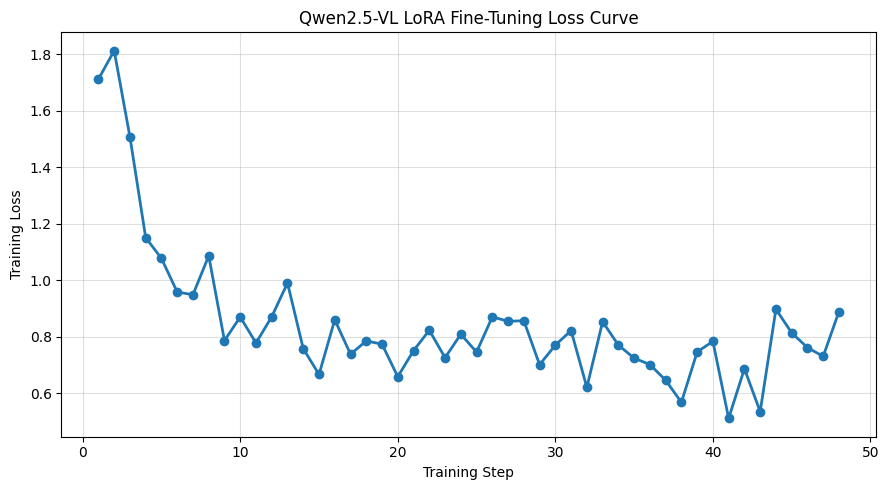

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures/training_loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(df_loss["step"], df_loss["loss"], marker="o", linewidth=2)
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Qwen2.5-VL LoRA Fine-Tuning Loss Curve")
plt.grid(True, alpha=0.4)
plt.tight_layout()

loss_path = FIG_DIR / "training_loss_curve.png"
plt.savefig(loss_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)

## 7. Smoothed Training Loss Curve

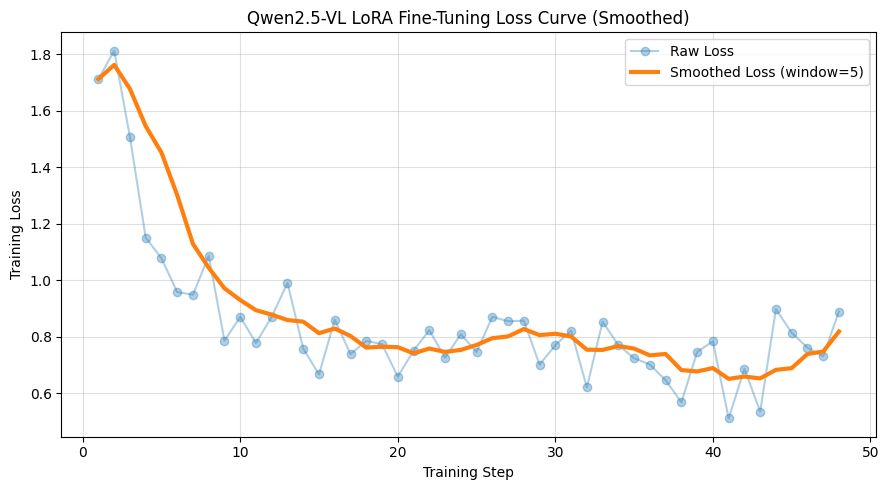

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures/training_loss_curve_smoothed.png


In [ ]:
window = 5
df_loss["loss_smooth"] = df_loss["loss"].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(9, 5))
plt.plot(df_loss["step"], df_loss["loss"], marker="o", alpha=0.35, label="Raw Loss")
plt.plot(df_loss["step"], df_loss["loss_smooth"], linewidth=3, label=f"Smoothed Loss (window={window})")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Qwen2.5-VL LoRA Fine-Tuning Loss Curve (Smoothed)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()

smooth_loss_path = FIG_DIR / "training_loss_curve_smoothed.png"
plt.savefig(smooth_loss_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", smooth_loss_path)

## 8. Learning Rate Schedule

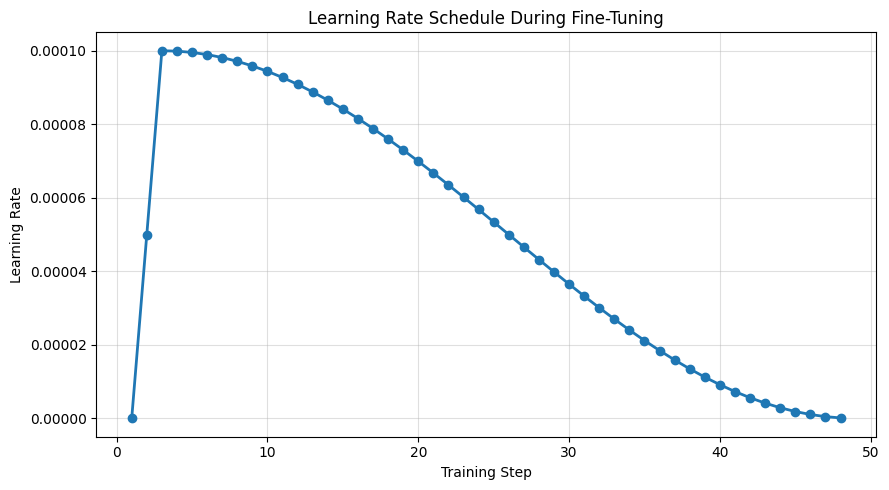

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures/learning_rate_schedule.png


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df_loss["step"], df_loss["learning_rate"], marker="o", linewidth=2)
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule During Fine-Tuning")
plt.grid(True, alpha=0.4)
plt.tight_layout()

lr_path = FIG_DIR / "learning_rate_schedule.png"
plt.savefig(lr_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", lr_path)

## 9. Loss Summary Table

In [ ]:
loss_summary = {
    "Initial Loss": df_loss["loss"].iloc[0],
    "Final Logged Loss": df_loss["loss"].iloc[-1],
    "Minimum Loss": df_loss["loss"].min(),
    "Maximum Loss": df_loss["loss"].max(),
    "Mean Loss": df_loss["loss"].mean(),
    "Loss Reduction": df_loss["loss"].iloc[0] - df_loss["loss"].iloc[-1],
    "Loss Reduction (%)": ((df_loss["loss"].iloc[0] - df_loss["loss"].iloc[-1]) / df_loss["loss"].iloc[0]) * 100,
}

df_loss_summary = pd.DataFrame(
    [{"Metric": k, "Value": round(v, 4)} for k, v in loss_summary.items()]
)

display(df_loss_summary)

,Metric,Value
0,Initial Loss,1.7121
1,Final Logged Loss,0.8888
2,Minimum Loss,0.5107
3,Maximum Loss,1.8126
4,Mean Loss,0.8488
5,Loss Reduction,0.8233
6,Loss Reduction (%),48.0848


## 10. Training Configuration Table

In [ ]:
training_config = {
    "Base Model": "Qwen/Qwen2.5-VL-3B-Instruct",
    "Fine-Tuning Method": "LoRA",
    "Dataset": "mrdbourke/FoodExtract-1k-Vision",
    "Task": "Image to structured JSON extraction",
    "Epoch": "1",
    "Training Steps": str(trainer_state.get("global_step", "N/A")),
    "Precision": "bf16",
    "FlashAttention2": "Disabled",
    "Liger Kernel": "Disabled",
    "TF32": "Disabled",
    "Vision Tower": "Frozen",
    "LLM Backbone": "Frozen",
    "Trainable Part": "LoRA adapters + non-LoRA states",
}

df_training_config = pd.DataFrame(
    [{"Parameter": k, "Value": v} for k, v in training_config.items()]
)

display(df_training_config)

,Parameter,Value
0,Base Model,Qwen/Qwen2.5-VL-3B-Instruct
1,Fine-Tuning Method,LoRA
2,Dataset,mrdbourke/FoodExtract-1k-Vision
3,Task,Image to structured JSON extraction
4,Epoch,1
5,Training Steps,48
6,Precision,bf16
7,FlashAttention2,Disabled
8,Liger Kernel,Disabled
9,TF32,Disabled


## 11. LoRA Adapter Configuration

In [ ]:
adapter_config_path = OUTPUT_DIR / "adapter_config.json"

with open(adapter_config_path, "r", encoding="utf-8") as f:
    adapter_config = json.load(f)

important_lora_keys = [
    "peft_type",
    "task_type",
    "r",
    "lora_alpha",
    "lora_dropout",
    "bias",
    "target_modules",
]

rows = []
for k in important_lora_keys:
    if k in adapter_config:
        rows.append({"Parameter": k, "Value": str(adapter_config[k])})

df_lora_config = pd.DataFrame(rows)
display(df_lora_config)

,Parameter,Value
0,peft_type,LORA
1,task_type,None
2,r,32
3,lora_alpha,64
4,lora_dropout,0.05
5,bias,none
6,target_modules,"['layers.13.mlp.gate_proj', '35.mlp.down_proj'..."


## 12. Output Artifact Summary

In [ ]:
artifact_explanations = {
    "adapter_model.safetensors": "Fine-tuned LoRA adapter weights",
    "adapter_config.json": "LoRA configuration",
    "trainer_state.json": "Training logs, loss values, learning-rate history",
    "non_lora_state_dict.bin": "Additional trained non-LoRA parameters",
    "checkpoint-48": "Training checkpoint",
    "processor_config.json": "Processor configuration",
    "tokenizer.json": "Tokenizer file",
    "tokenizer_config.json": "Tokenizer configuration",
    "chat_template.jinja": "Chat template used for prompting",
    "config.json": "Model/adapter configuration",
}

artifact_rows = []
for name, desc in artifact_explanations.items():
    p = OUTPUT_DIR / name
    artifact_rows.append({
        "Artifact": name,
        "Exists": p.exists(),
        "Description": desc
    })

df_artifacts = pd.DataFrame(artifact_rows)
display(df_artifacts)

,Artifact,Exists,Description
0,adapter_model.safetensors,True,Fine-tuned LoRA adapter weights
1,adapter_config.json,True,LoRA configuration
2,trainer_state.json,True,"Training logs, loss values, learning-rate history"
3,non_lora_state_dict.bin,True,Additional trained non-LoRA parameters
4,checkpoint-48,True,Training checkpoint
5,processor_config.json,True,Processor configuration
6,tokenizer.json,True,Tokenizer file
7,tokenizer_config.json,True,Tokenizer configuration
8,chat_template.jinja,True,Chat template used for prompting
9,config.json,True,Model/adapter configuration


## 13. Artifact Size Chart

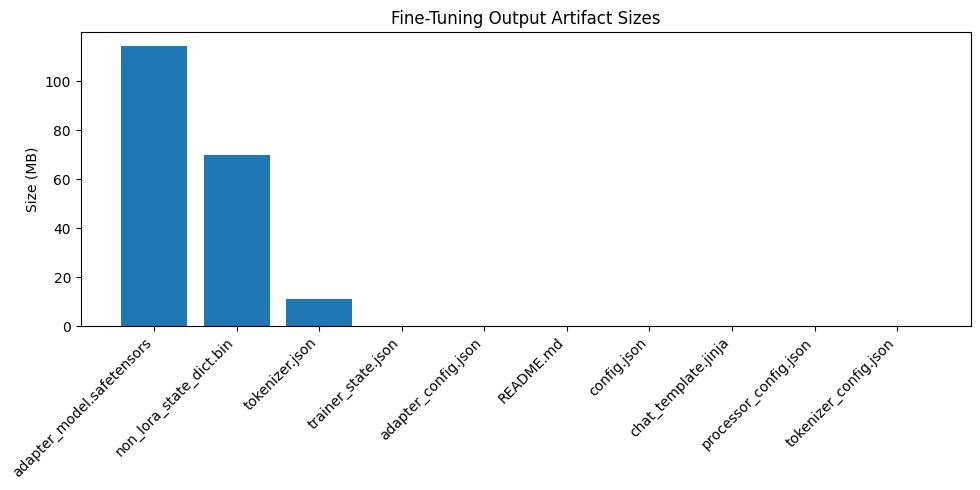

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures/artifact_size_chart.png


In [ ]:
df_file_sizes = df_files[df_files["type"] == "file"].copy()
df_file_sizes = df_file_sizes[df_file_sizes["size_mb"] != "-"]
df_file_sizes["size_mb"] = df_file_sizes["size_mb"].astype(float)
df_file_sizes = df_file_sizes.sort_values("size_mb", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(df_file_sizes["name"], df_file_sizes["size_mb"])
plt.ylabel("Size (MB)")
plt.title("Fine-Tuning Output Artifact Sizes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

artifact_size_path = FIG_DIR / "artifact_size_chart.png"
plt.savefig(artifact_size_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", artifact_size_path)

## 14. Fine-Tuning Pipeline Diagram

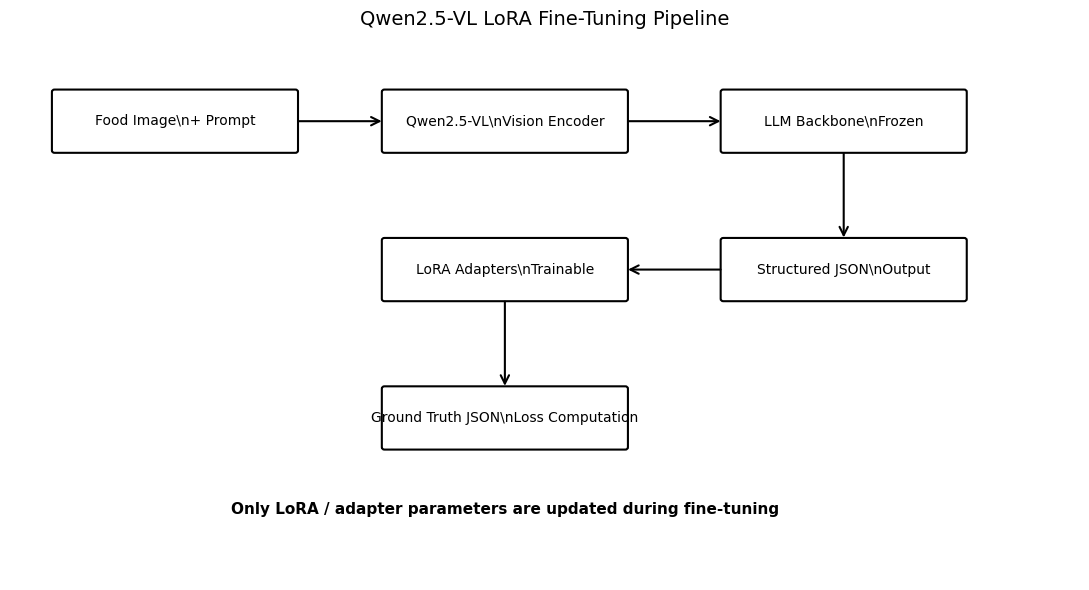

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetune_figures/qwen_lora_finetuning_pipeline.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, text, width=2.7, height=0.75):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha="center", va="center", fontsize=10)
    return box

def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

add_box(ax, (0.5, 5.5), "Food Image\\n+ Prompt")
add_box(ax, (4.2, 5.5), "Qwen2.5-VL\\nVision Encoder")
add_box(ax, (8.0, 5.5), "LLM Backbone\\nFrozen")

add_box(ax, (4.2, 3.6), "LoRA Adapters\\nTrainable")
add_box(ax, (8.0, 3.6), "Structured JSON\\nOutput")
add_box(ax, (4.2, 1.7), "Ground Truth JSON\\nLoss Computation")

add_arrow(ax, (3.2, 5.875), (4.2, 5.875))
add_arrow(ax, (6.9, 5.875), (8.0, 5.875))
add_arrow(ax, (9.35, 5.5), (9.35, 4.35))
add_arrow(ax, (8.0, 3.975), (6.9, 3.975))
add_arrow(ax, (5.55, 3.6), (5.55, 2.45))

ax.text(
    5.55, 0.85,
    "Only LoRA / adapter parameters are updated during fine-tuning",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.title("Qwen2.5-VL LoRA Fine-Tuning Pipeline", fontsize=14)
plt.tight_layout()

pipeline_path = FIG_DIR / "qwen_lora_finetuning_pipeline.png"
plt.savefig(pipeline_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", pipeline_path)

## 15. Summary Markdown Üretme

In [ ]:
loss_reduction_percent = ((df_loss["loss"].iloc[0] - df_loss["loss"].iloc[-1]) / df_loss["loss"].iloc[0]) * 100

summary_md = f'''# Qwen2.5-VL LoRA Fine-Tuning Summary

## Model and Dataset
- Base Model: Qwen/Qwen2.5-VL-3B-Instruct
- Dataset: mrdbourke/FoodExtract-1k-Vision
- Task: Food image to structured JSON extraction
- Method: LoRA fine-tuning

## Training Output
- Output directory: `{OUTPUT_DIR}`
- Global step: {trainer_state.get("global_step", "N/A")}
- Epoch: {trainer_state.get("epoch", "N/A")}

## Loss Summary
- Initial Loss: {df_loss["loss"].iloc[0]:.4f}
- Final Logged Loss: {df_loss["loss"].iloc[-1]:.4f}
- Minimum Loss: {df_loss["loss"].min():.4f}
- Mean Loss: {df_loss["loss"].mean():.4f}
- Loss Reduction: {loss_reduction_percent:.2f}%

## Generated Figures
- training_loss_curve.png
- training_loss_curve_smoothed.png
- learning_rate_schedule.png
- artifact_size_chart.png
- qwen_lora_finetuning_pipeline.png
'''

summary_path = EVAL_DIR / "finetuning_summary.md"
summary_path.write_text(summary_md, encoding="utf-8")

print(summary_md)
print("Saved:", summary_path)

# Qwen2.5-VL LoRA Fine-Tuning Summary

## Model and Dataset
- Base Model: Qwen/Qwen2.5-VL-3B-Instruct
- Dataset: mrdbourke/FoodExtract-1k-Vision
- Task: Food image to structured JSON extraction
- Method: LoRA fine-tuning

## Training Output
- Output directory: `/content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/outputs/qwen25vl_foodextract_lora_full`
- Global step: 48
- Epoch: 1.0

## Loss Summary
- Initial Loss: 1.7121
- Final Logged Loss: 0.8888
- Minimum Loss: 0.5107
- Mean Loss: 0.8488
- Loss Reduction: 48.08%

## Generated Figures
- training_loss_curve.png
- training_loss_curve_smoothed.png
- learning_rate_schedule.png
- artifact_size_chart.png
- qwen_lora_finetuning_pipeline.png

Saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/eval/finetuning_summary.md


## 16. Figürleri Zip Yapma

In [ ]:
zip_path = BASE_DIR / "finetuning_visualizations.zip"

!cd "{FIG_DIR}" && zip -r "{zip_path}" .

print("ZIP saved:", zip_path)

  adding: training_loss_curve.png (deflated 12%)
  adding: training_loss_curve_smoothed.png (deflated 9%)
  adding: learning_rate_schedule.png (deflated 17%)
  adding: artifact_size_chart.png (deflated 16%)
  adding: qwen_lora_finetuning_pipeline.png (deflated 27%)
ZIP saved: /content/drive/MyDrive/BENCHMARK/QUWEN/foodextract_project/foodextract_qwen_project/finetuning_visualizations.zip
